In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets.packaged_modules.webdataset.webdataset import torch_loads
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json

from torch.utils.data import TensorDataset, DataLoader

from scoit.cell_analysis import umap_visualize
from hgnn.hypergraph import *
from sklearn.preprocessing import MinMaxScaler

In [2]:
from examples.case_studies.sc_GEM_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [4]:
len(labels)

224

In [20]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(data == 0, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [21]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 59
After remove all nan 34
After remove all zeros 33
Input #cols 59
After remove all nan 27
After remove all zeros 27


Text(0.5, 1.0, 'methylation_data_clean')

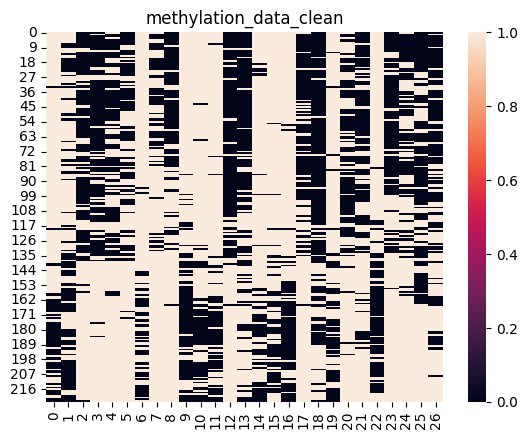

In [7]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

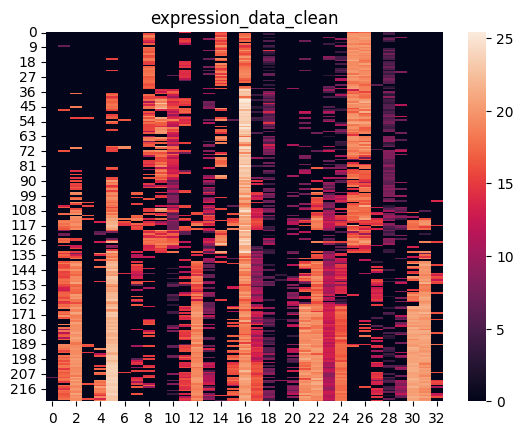

In [8]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [27]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [28]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [29]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3023, 3), (3023,), (3782, 3), (3782,))

In [30]:
expression_edges.max(0), methylation_edges.max(0)

(array([223,  32,   0]), array([223,  59,   1]))

In [31]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [32]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [33]:
edges.shape, weights.shape

((6805, 3), (6805,))

In [34]:
np.any(weights == 0)

False

In [35]:
save_edges_and_weights('./data/sc_GEM', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [36]:
train_data = np.load('./data/sc_GEM/train_data.npz', allow_pickle=True)
test_data = np.load('./data/sc_GEM/test_data.npz', allow_pickle=True)

In [39]:
train_data['nums_type']

array([224,  60,   2])

In [54]:
!python hgnn/main_torch_zinb.py --data sc_GEM --feature adj --loss gauss --iter 50

1.0 -0.5
model_no_randomwalk
Use train_weight (5444,)
Node type num [224  60   2]
[ 1.       17.693695  2.257469 ...  9.007356 14.703015  1.      ] 1.0 24.974277
walk type 
adding pad idx
dict_size 5444 6805
train data amount 5444
64
tensor([  0, 224, 284, 286], device='cuda:0')
w.shape (224, 62)
(224, 62)
w.shape (60, 226)
(60, 226)
w.shape (2, 284)
(2, 284)
self.input_size [62, 226, 284]
inp 62 out 64 weight.shape torch.Size([64, 62])
fan_in 62 7.874007874011811
inp 226 out 64 weight.shape torch.Size([64, 226])
fan_in 226 15.033296378372908
inp 284 out 64 weight.shape torch.Size([64, 284])
fan_in 284 16.852299546352718
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]]               0
         LayerNorm-2                [-1, 3, 64]             128
         LayerNorm-3                [-1, 3, 64]             128
         LayerNorm-4    

In [10]:
cell_embeddings = np.load('./embeddings/sc_GEM/mymodel_0.npy', allow_pickle=True)
gene_embeddings = np.load('./embeddings/sc_GEM/mymodel_1.npy', allow_pickle=True)
omic_embeddings = np.load('./embeddings/sc_GEM/mymodel_2.npy', allow_pickle=True)


In [57]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 57K Nov 10 14:26 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 57K Nov 10 14:26 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs 16K Nov 10 14:26 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs 16K Nov 10 14:26 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 14:26 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 14:26 ./mymodel_2_origin.npy


In [58]:
cell_embeddings.shape

(224, 64)

{'NMI': 0.5068629215196627,
 'ARI': 0.3496237909068295,
 'FMI': 0.4366895577091435}

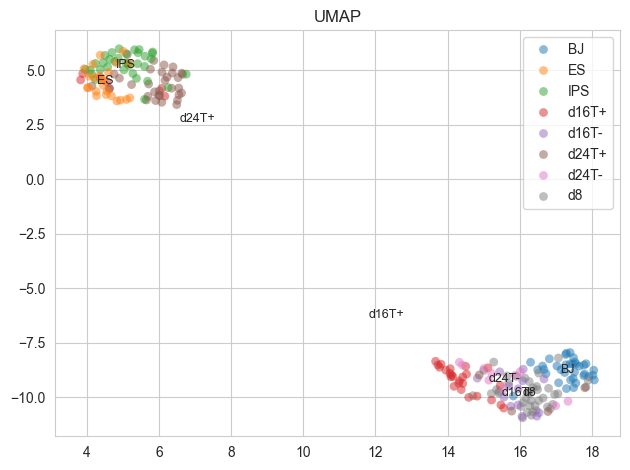

In [6]:
umap_visualize(cell_embeddings, labels)

In [60]:
!mkdir -p ./embeddings/hgnn/sc_GEM

In [61]:
!mv ./*.npy ./embeddings/hgnn/sc_GEM


<Axes: >

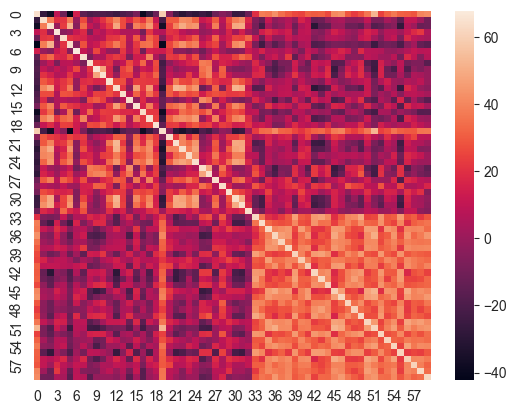

In [7]:
sns.heatmap(gene_embeddings @ gene_embeddings.T)

<Axes: >

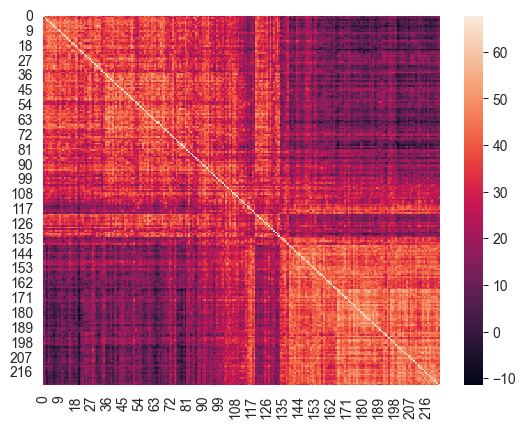

In [9]:
sns.heatmap(cell_embeddings @ cell_embeddings.T)

In [135]:
from torch.utils.data import TensorDataset, DataLoader
from torch import nn
from torch.optim import Adam
from torch.nn.functional import mse_loss, relu
import torch.nn.functional as F
import torch

In [109]:
class PhasingModel(nn.Module):

    def __init__(self, embed_dim, activations, omics_offset):
        super().__init__()
        self.omics_offset = omics_offset
        self.activations = activations

        self.fc_gene_p = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.fc_gene_m = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def forward(self, G, C):
        act1, act2 = self.activations
        latent_p = C @ self.fc_gene_p(G).T
        latent_m = C @ self.fc_gene_m(G).T
        Xp = torch.cat([act1(latent_p[:, 0:self.omics_offset]), act2(latent_p[:, self.omics_offset:])], dim=1)
        Xm = torch.cat([act1(latent_m[:, 0:self.omics_offset]), act2(latent_m[:, self.omics_offset:])], dim=1)
        return Xp, Xm

    @torch.no_grad()
    def predict(self, G, C):
        Xp, Xm = self.forward(G, C)
        return Xp.cpu().numpy(), Xm.cpu().numpy()

    def reconstruct(self, G, C):
        Xp, Xm = self.forward(G, C)
        return Xp + Xm


In [30]:
G = torch.tensor(gene_embeddings, dtype=torch.float)
C = torch.tensor(cell_embeddings, dtype=torch.float)
X = torch.tensor(np.concatenate([expression_data_clean, methylation_data_clean], axis=1), dtype=torch.float)

Epoch 0 Loss 177.26136779785156
Epoch 1 Loss 95.05080699920654
Epoch 2 Loss 73.81543922424316
Epoch 3 Loss 65.19928741455078
Epoch 4 Loss 59.30545902252197
Epoch 5 Loss 54.15407085418701
Epoch 6 Loss 50.479347705841064
Epoch 7 Loss 48.34549140930176
Epoch 8 Loss 46.023826599121094
Epoch 9 Loss 44.476327896118164
Epoch 10 Loss 43.56243324279785
Epoch 11 Loss 42.0834059715271
Epoch 12 Loss 40.555864334106445
Epoch 13 Loss 38.88946008682251
Epoch 14 Loss 38.0357141494751
Epoch 15 Loss 38.1397066116333
Epoch 16 Loss 37.66746473312378
Epoch 17 Loss 36.82691431045532
Epoch 18 Loss 35.74646329879761
Epoch 19 Loss 34.8190336227417
Epoch 20 Loss 35.30726861953735
Epoch 21 Loss 34.18929147720337
Epoch 22 Loss 33.51738977432251
Epoch 23 Loss 32.501609325408936
Epoch 24 Loss 32.085047245025635
Epoch 25 Loss 31.94378900527954
Epoch 26 Loss 31.422532558441162
Epoch 27 Loss 32.001795291900635
Epoch 28 Loss 31.919706344604492
Epoch 29 Loss 31.121013164520264
Epoch 30 Loss 31.195958137512207
Epoch 31 L

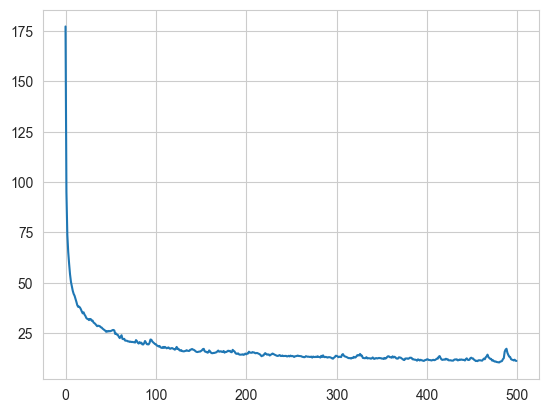

In [166]:
epochs = 500
model = PhasingModel(embed_dim=64, activations=[F.softplus, F.sigmoid], omics_offset=expression_data_clean.shape[1])
optimizer = Adam(model.parameters(), lr=1e-2)
history = []
cell_dataset = TensorDataset(C, X)
dataloader = DataLoader(cell_dataset, shuffle=True, batch_size=32)

for i in range(epochs):
    loss_ep = 0
    for c, x in dataloader:
        X_hat = model.reconstruct(G, c)
        # cxp = c @ model.fc_gene_p(G).T
        # cxm = c @ model.fc_gene_m(G).T
        loss = mse_loss(X_hat, x) #+ mse_loss(cxp, cxm) * 0.01
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_ep += loss.item()

    history.append(loss_ep)
    print('Epoch', i, 'Loss', loss_ep)

plt.plot(history)

In [167]:
Gp = model.fc_gene_p(G).detach().numpy()
Gm = model.fc_gene_m(G).detach().numpy()


<Axes: >

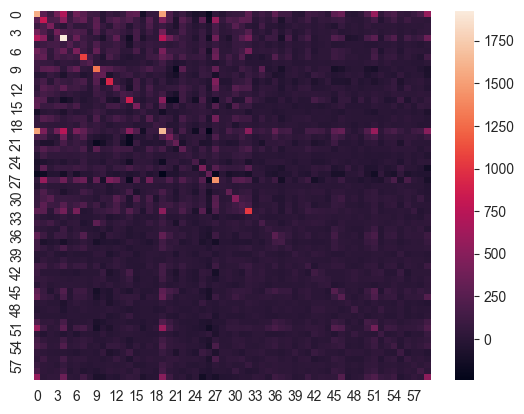

In [168]:
sns.heatmap(Gp @ Gp.T)

<Axes: >

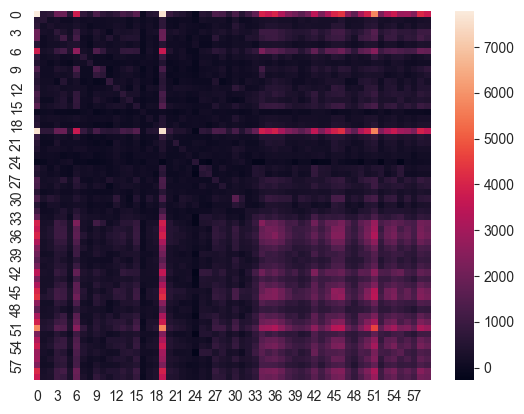

In [169]:
sns.heatmap(Gm @ Gm.T)

In [170]:
Xp, Xm = model.predict(G, C)

Text(0.5, 1.0, 'X')

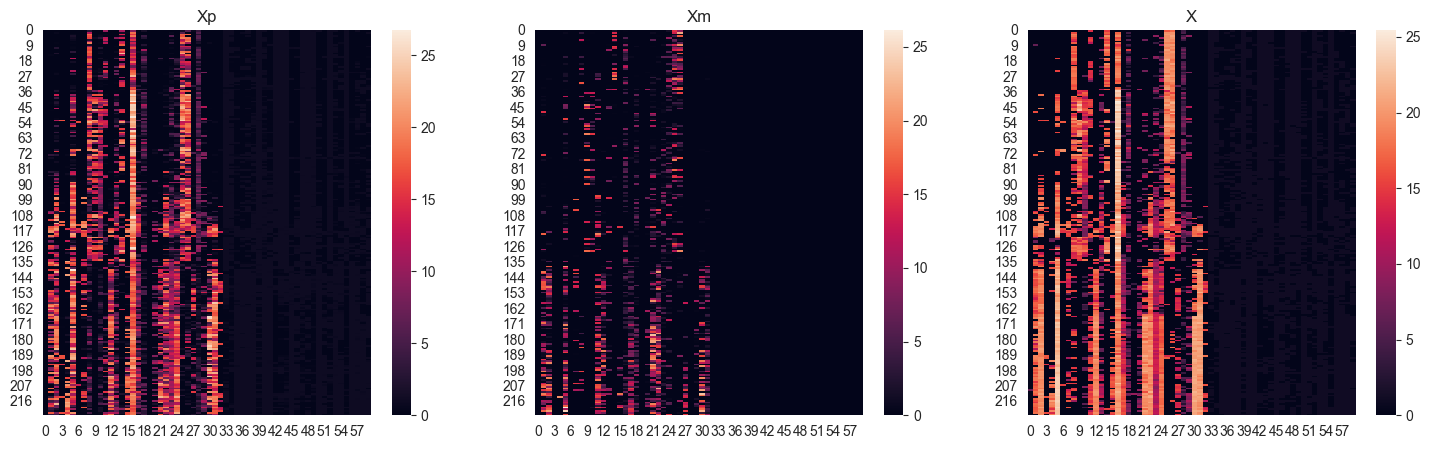

In [171]:
plt.figure(figsize=(18,5))
ax = plt.subplot(131)
sns.heatmap(Xp,ax=ax)
plt.title('Xp')
ax = plt.subplot(132)
sns.heatmap(Xm,ax=ax)
plt.title('Xm')
ax = plt.subplot(133)
sns.heatmap(X,ax=ax)
plt.title('X')

In [172]:
Xp_expression, Xp_methylation = Xp[:, :expression_data_clean.shape[1]], Xp[:, expression_data_clean.shape[1]:]
Xm_expression, Xm_methylation = Xm[:, :expression_data_clean.shape[1]], Xm[:, expression_data_clean.shape[1]:]

Xp_methylation = (Xp_methylation > 0.5).astype(int)
Xm_methylation = (Xm_methylation > 0.5).astype(int)

Text(0.5, 1.0, 'X_methylation')

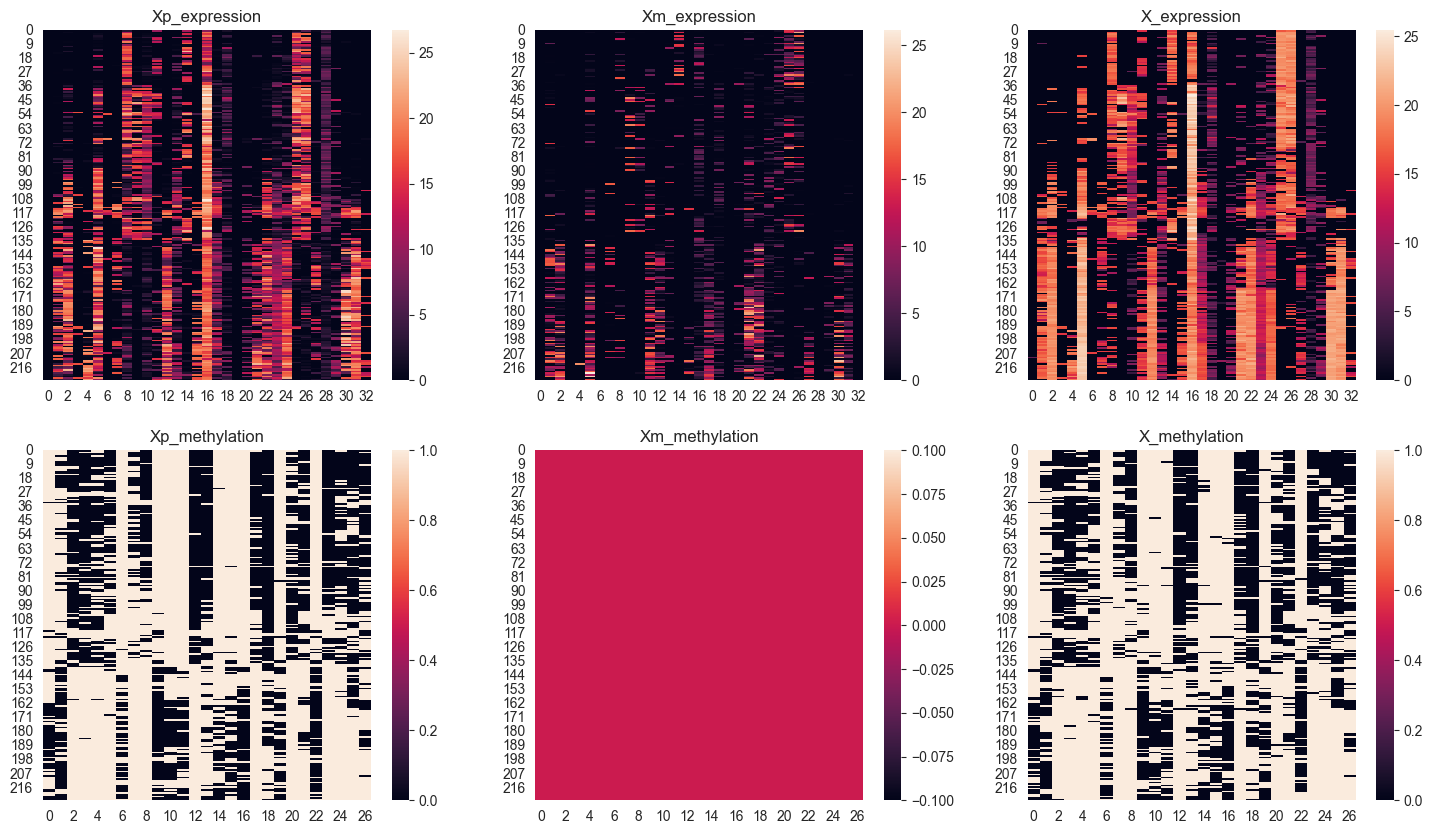

In [173]:
plt.figure(figsize=(18,10))
ax = plt.subplot(231)
sns.heatmap(Xp_expression,ax=ax)
plt.title('Xp_expression')
ax = plt.subplot(232)
sns.heatmap(Xm_expression,ax=ax)
plt.title('Xm_expression')
ax = plt.subplot(233)
sns.heatmap(expression_data_clean,ax=ax)
plt.title('X_expression')
ax = plt.subplot(234)
sns.heatmap(Xp_methylation,ax=ax)
plt.title('Xp_methylation')
ax = plt.subplot(235)
sns.heatmap(Xm_methylation,ax=ax)
plt.title('Xm_methylation')
ax = plt.subplot(236)
sns.heatmap(methylation_data_clean,ax=ax)
plt.title('X_methylation')

{'NMI': 0.6628782572446952,
 'ARI': 0.5595237982689852,
 'FMI': 0.6185331733549865}

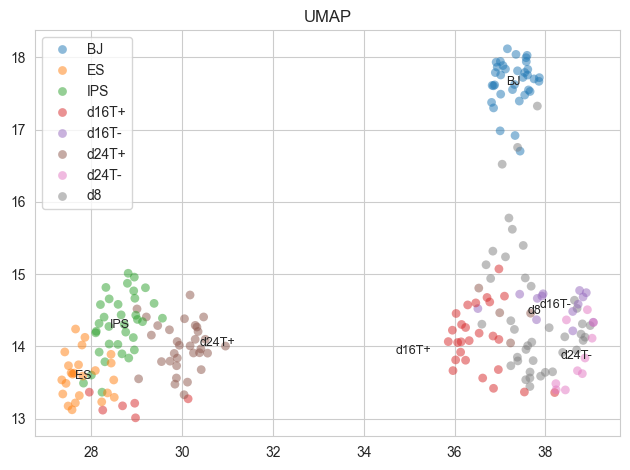

In [141]:
umap_visualize(X, labels)

{'NMI': 0.46540578985076725,
 'ARI': 0.2683329943063811,
 'FMI': 0.36857636729203275}

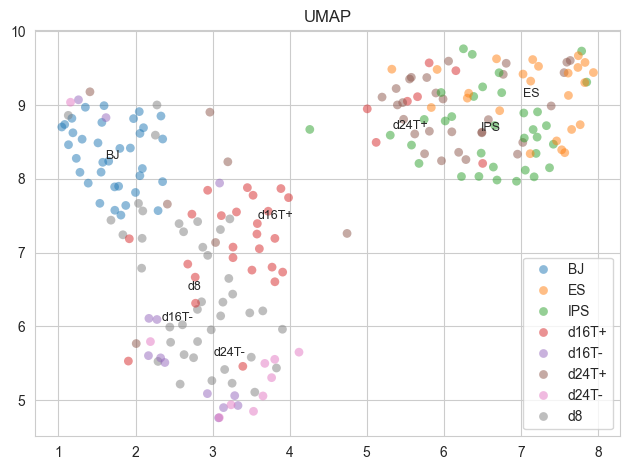

In [156]:
umap_visualize(Xp, labels)

{'NMI': 0.4273227471568227,
 'ARI': 0.2303674050168911,
 'FMI': 0.34044861281500993}

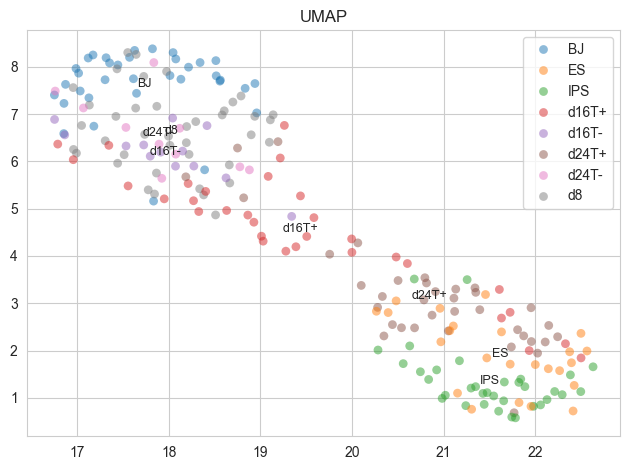

In [157]:
umap_visualize(Xm, labels)

{'NMI': 0.47054241645901246,
 'ARI': 0.33744876719934636,
 'FMI': 0.43368236866536725}

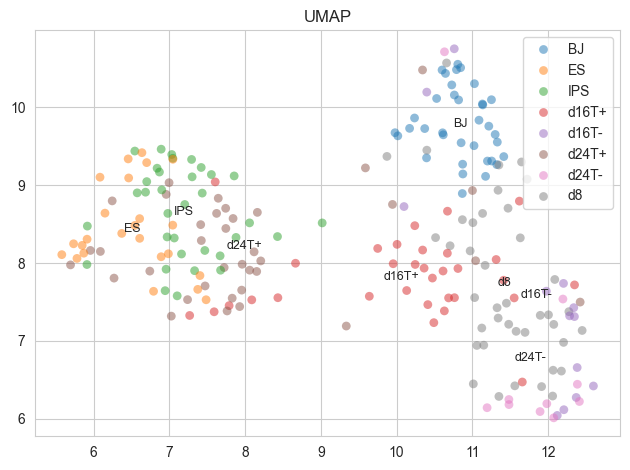

In [158]:
umap_visualize(Xp_expression, labels)

{'NMI': 0.428172037169008,
 'ARI': 0.27790819078317336,
 'FMI': 0.3785080084789291}

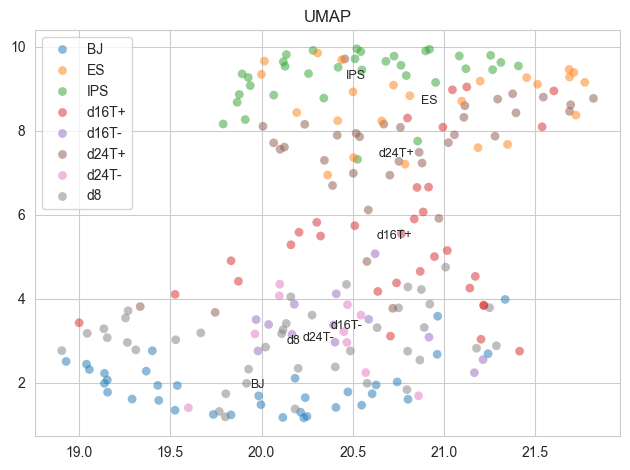

In [159]:
umap_visualize(Xm_expression, labels)

{'NMI': 0.3408436722638156,
 'ARI': 0.14870203263037643,
 'FMI': 0.3002826943070915}

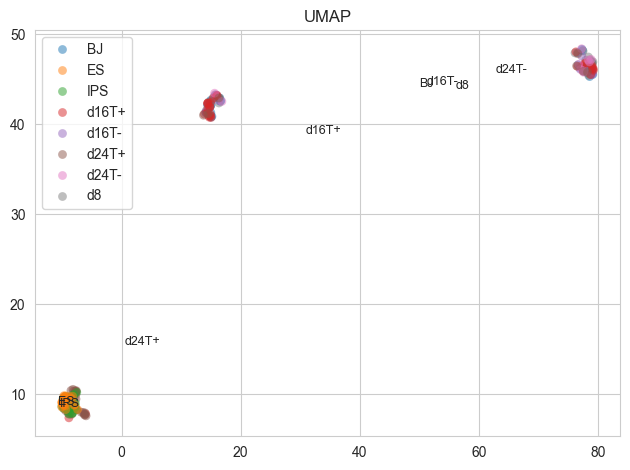

In [160]:
umap_visualize(Xp_methylation, labels)

{'NMI': 0.24498683086711612,
 'ARI': 0.0925508085911158,
 'FMI': 0.24228735306168803}

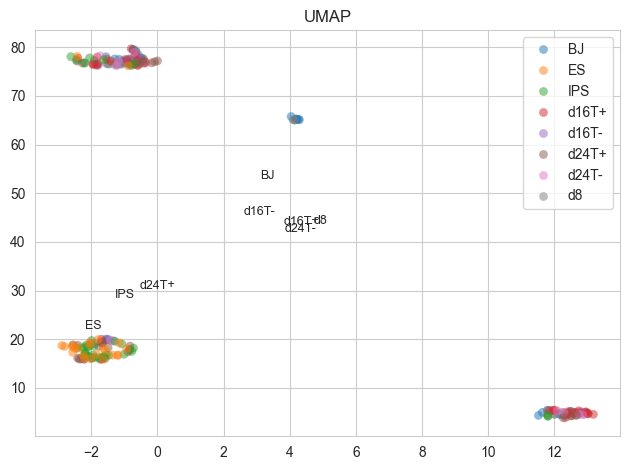

In [161]:
umap_visualize(Xm_methylation, labels)

{'NMI': 0.6528485577581006,
 'ARI': 0.5294446174755082,
 'FMI': 0.6006081194306532}

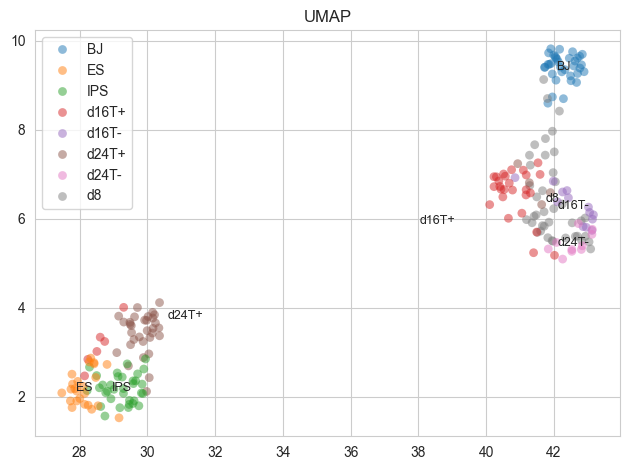

In [149]:
umap_visualize(expression_data_clean, labels)

{'NMI': 0.3960620675625873,
 'ARI': 0.22969154263335673,
 'FMI': 0.3354387259823922}

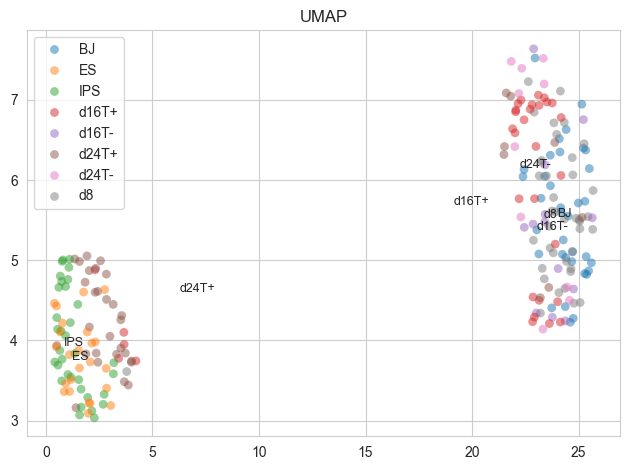

In [150]:
umap_visualize(methylation_data_clean, labels)